# 5.2 K-Means Clustering — Per Polutan

Notebook ini menjalankan **K-Means Clustering** untuk masing-masing polutan (CO, NO₂, SO₂) pada dua skenario:

| Skenario | Input | Keterangan |
|----------|-------|------------|
| **Skenario 1** | 68 fitur asli | Tanpa reduksi dimensi |
| **Skenario 2** | 37 fitur PCA | Dengan reduksi dimensi |

Untuk masing-masing skenario, dicari **jumlah cluster optimal (K)** menggunakan **Elbow Method** dan **Silhouette Score**.

**Dataset:** Dataset gabungan kelas (35 mahasiswa × 68 fitur per polutan)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10

POLLUTANTS = ['CO', 'NO2', 'SO2']
DATA_DIR = '../data/downloads/ekstraksi fitur'
META_COLS = ['id', 'nama', 'daerah']
K_range = range(2, 11)

## 5.2.1 Memuat Data

Load dataset gabungan kelas untuk setiap polutan, lalu ekstraksi 68 fitur asli.

In [2]:
X_dict = {}
X_scaled_dict = {}
scaler_dict = {}

for p in POLLUTANTS:
    path = f'{DATA_DIR}/ekstraksi_fitur_{p.lower()}.csv'
    df = pd.read_csv(path)
    X = df.drop(columns=META_COLS).values
    
    # Handle NaN values with median imputation
    nan_count = np.isnan(X).sum()
    if nan_count > 0:
        print(f'{p}: Ditemukan {nan_count} nilai NaN, melakukan imputasi median...')
        imputer = SimpleImputer(strategy='median')
        X = imputer.fit_transform(X)
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    X_dict[p] = X
    X_scaled_dict[p] = X_scaled
    scaler_dict[p] = scaler
    
    print(f'{p}: {X_scaled.shape[0]} data x {X_scaled.shape[1]} fitur')

CO: Ditemukan 24 nilai NaN, melakukan imputasi median...
CO: 35 data x 68 fitur
NO2: 37 data x 68 fitur
SO2: Ditemukan 24 nilai NaN, melakukan imputasi median...
SO2: 35 data x 68 fitur


In [3]:
# Load hasil PCA dari notebook 5.1
X_pca_dict = {}
n_samples = X_scaled_dict[POLLUTANTS[0]].shape[0]
target_n_components = min(37, n_samples)  # Tidak bisa melebihi jumlah sampel

for p in POLLUTANTS:
    loaded = False
    # Coba load dengan berbagai kemungkinan nama file
    for n_comp in [37, target_n_components, 35]:
        try:
            df_pca = pd.read_csv(f'{DATA_DIR}/pca_results/jabon_pca_{n_comp}fitur_{p.lower()}.csv')
            X_pca = df_pca.drop(columns=META_COLS).values
            X_pca_dict[p] = X_pca
            print(f'{p} PCA: {X_pca.shape[0]} data x {X_pca.shape[1]} fitur')
            loaded = True
            break
        except FileNotFoundError:
            continue
    
    if not loaded:
        print(f'{p}: File PCA tidak ditemukan, melakukan PCA ulang...')
        pca = PCA(n_components=target_n_components)
        X_pca = pca.fit_transform(X_scaled_dict[p])
        X_pca_dict[p] = X_pca
        print(f'{p} PCA (ulang): {X_pca.shape[0]} data x {X_pca.shape[1]} fitur')

CO PCA: 35 data x 35 fitur
NO2 PCA: 37 data x 37 fitur
SO2 PCA: 35 data x 35 fitur


## 5.2.2 Menentukan K Optimal

### Elbow Method
Mencari *elbow* pada kurva inertia (Within-Cluster Sum of Squares). Titik di mana penurunan inertia mulai melambat menandakan K optimal.

### Silhouette Score
Mengukur seberapa mirip sebuah titik dengan cluster-nya sendiri dibandingkan cluster lain. Skor mendekati 1 = cluster yang baik.

In [4]:
def find_optimal_k(X, label_prefix=''):
    """Jalankan K-Means untuk K=2..10, kembalikan inertia + silhouette."""
    inertias = []
    silhouettes = []
    
    for k in K_range:
        km = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
        labels = km.fit_predict(X)
        inertias.append(km.inertia_)
        sil = silhouette_score(X, labels)
        silhouettes.append(sil)
        print(f'  {label_prefix} K={k}: inertia={km.inertia_:.2f}, silhouette={sil:.4f}')
    
    best_k = list(K_range)[np.argmax(silhouettes)]
    best_sil = max(silhouettes)
    return inertias, silhouettes, best_k, best_sil

### Skenario 1: 68 Fitur Asli

In [5]:
results_68 = {}
for p in POLLUTANTS:
    print(f'\n=== SKENARIO 1: {p} — 68 Fitur ===')
    inertias, silhouettes, best_k, best_sil = find_optimal_k(X_scaled_dict[p], p)
    results_68[p] = {
        'inertias': inertias,
        'silhouettes': silhouettes,
        'best_k': best_k,
        'best_sil': best_sil
    }
    print(f'>>> K terbaik: K={best_k}, silhouette={best_sil:.4f}')


=== SKENARIO 1: CO — 68 Fitur ===
  CO K=2: inertia=1354.50, silhouette=0.7667
  CO K=3: inertia=675.65, silhouette=0.7506
  CO K=4: inertia=383.62, silhouette=0.6702
  CO K=5: inertia=301.02, silhouette=0.1404
  CO K=6: inertia=248.52, silhouette=0.1603
  CO K=7: inertia=195.86, silhouette=0.2096
  CO K=8: inertia=178.05, silhouette=0.1897
  CO K=9: inertia=157.20, silhouette=0.1385
  CO K=10: inertia=136.27, silhouette=0.1538
>>> K terbaik: K=2, silhouette=0.7667

=== SKENARIO 1: NO2 — 68 Fitur ===
  NO2 K=2: inertia=1326.82, silhouette=0.7450
  NO2 K=3: inertia=1001.18, silhouette=0.1911
  NO2 K=4: inertia=811.39, silhouette=0.2060
  NO2 K=5: inertia=666.18, silhouette=0.1929
  NO2 K=6: inertia=572.95, silhouette=0.1987
  NO2 K=7: inertia=511.69, silhouette=0.1591
  NO2 K=8: inertia=452.99, silhouette=0.1726
  NO2 K=9: inertia=406.45, silhouette=0.1825
  NO2 K=10: inertia=362.83, silhouette=0.1800
>>> K terbaik: K=2, silhouette=0.7450

=== SKENARIO 1: SO2 — 68 Fitur ===
  SO2 K=2: 

### Skenario 2: 37 Fitur PCA

In [6]:
results_pca = {}
for p in POLLUTANTS:
    print(f'\n=== SKENARIO 2: {p} — 37 PCA ===')
    inertias, silhouettes, best_k, best_sil = find_optimal_k(X_pca_dict[p], p)
    results_pca[p] = {
        'inertias': inertias,
        'silhouettes': silhouettes,
        'best_k': best_k,
        'best_sil': best_sil
    }
    print(f'>>> K terbaik: K={best_k}, silhouette={best_sil:.4f}')


=== SKENARIO 2: CO — 37 PCA ===
  CO K=2: inertia=1354.50, silhouette=0.7667
  CO K=3: inertia=675.65, silhouette=0.7506
  CO K=4: inertia=383.62, silhouette=0.6702
  CO K=5: inertia=301.02, silhouette=0.1404
  CO K=6: inertia=248.52, silhouette=0.1603
  CO K=7: inertia=195.86, silhouette=0.2096
  CO K=8: inertia=178.05, silhouette=0.1897
  CO K=9: inertia=157.20, silhouette=0.1385
  CO K=10: inertia=136.27, silhouette=0.1538
>>> K terbaik: K=2, silhouette=0.7667

=== SKENARIO 2: NO2 — 37 PCA ===
  NO2 K=2: inertia=1326.82, silhouette=0.7450
  NO2 K=3: inertia=1001.18, silhouette=0.1911
  NO2 K=4: inertia=811.39, silhouette=0.2060
  NO2 K=5: inertia=666.18, silhouette=0.1929
  NO2 K=6: inertia=572.95, silhouette=0.1987
  NO2 K=7: inertia=511.69, silhouette=0.1591
  NO2 K=8: inertia=452.99, silhouette=0.1726
  NO2 K=9: inertia=416.43, silhouette=0.1606
  NO2 K=10: inertia=362.83, silhouette=0.1800
>>> K terbaik: K=2, silhouette=0.7450

=== SKENARIO 2: SO2 — 37 PCA ===
  SO2 K=2: inerti

## 5.2.3 Visualisasi Elbow Method & Silhouette Score — Per Polutan

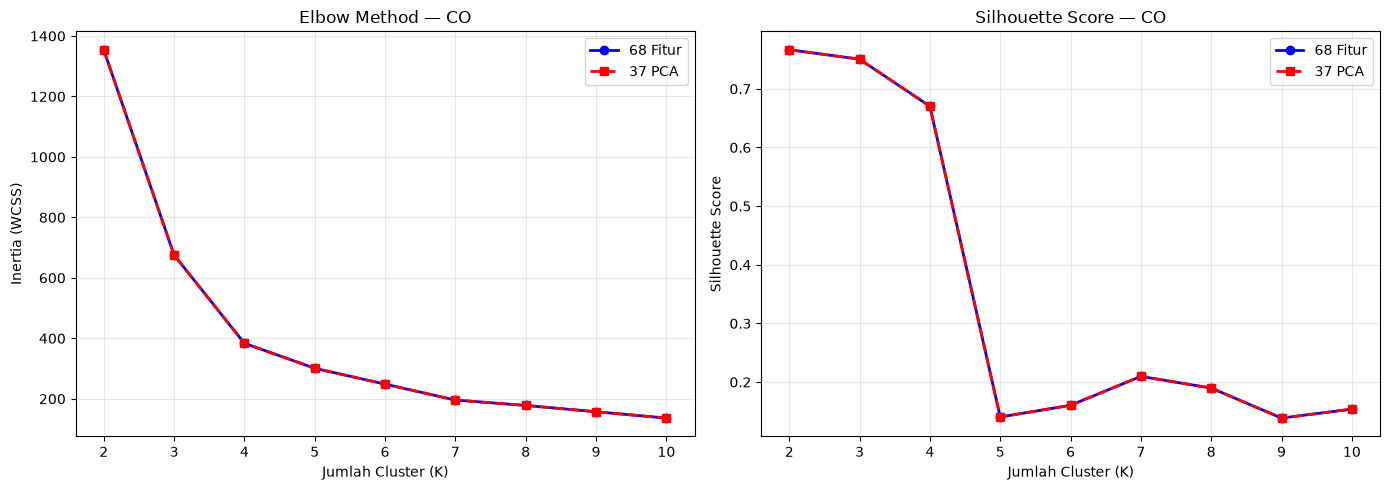

Tersimpan: fig_co_elbow_68.png


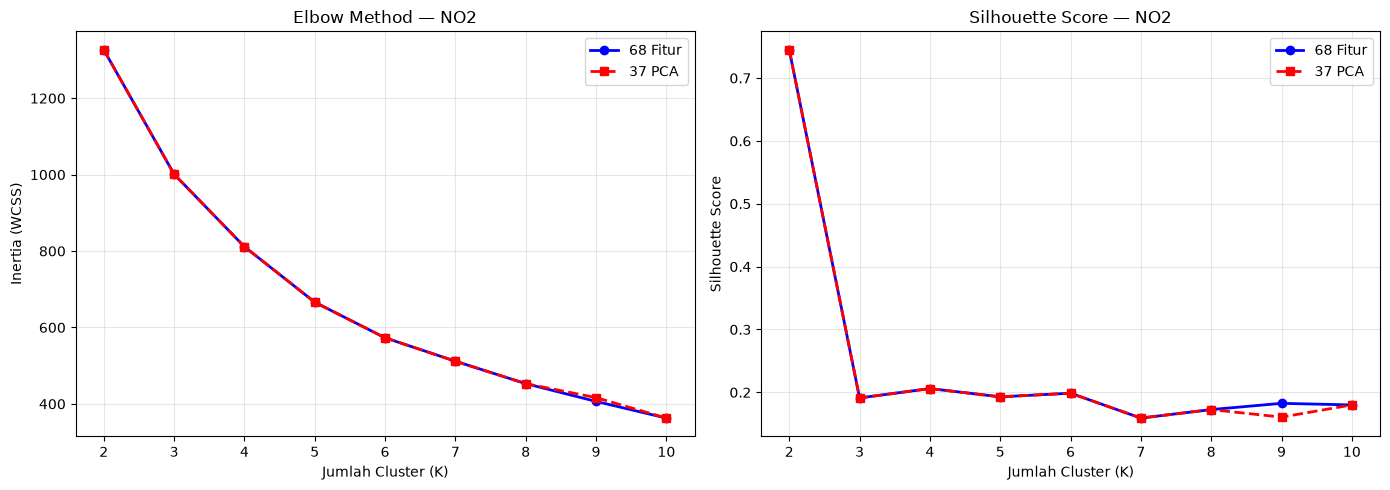

Tersimpan: fig_no2_elbow_68.png


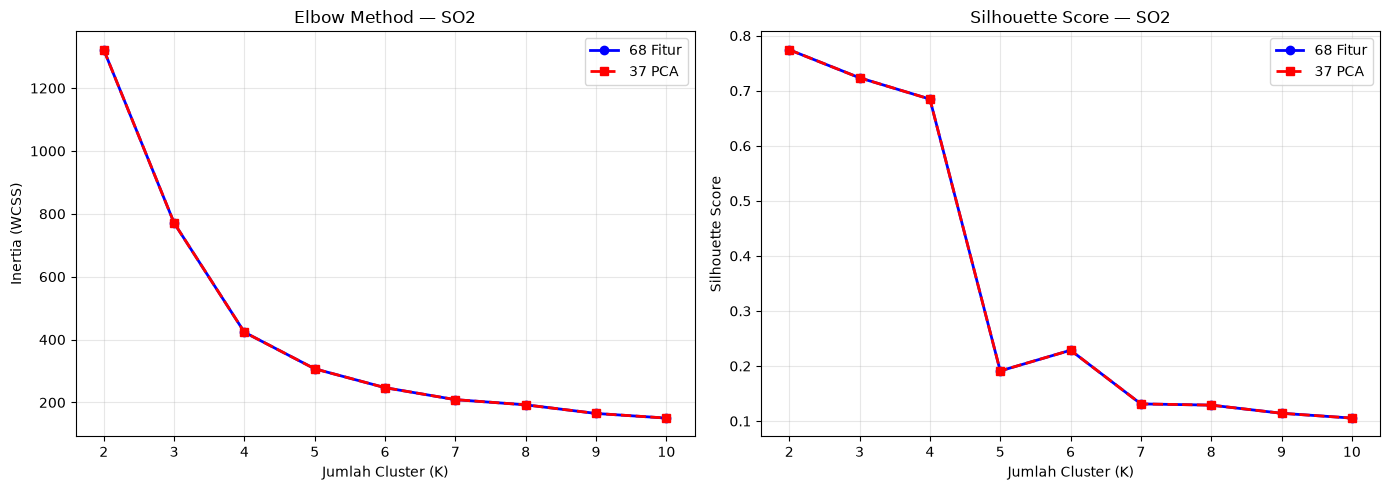

Tersimpan: fig_so2_elbow_68.png


In [7]:
for p in POLLUTANTS:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    inertias_68 = results_68[p]['inertias']
    sil_68 = results_68[p]['silhouettes']
    inertias_pca = results_pca[p]['inertias']
    sil_pca = results_pca[p]['silhouettes']
    
    # Elbow
    ax1.plot(list(K_range), inertias_68, 'bo-', label='68 Fitur', linewidth=2)
    ax1.plot(list(K_range), inertias_pca, 'rs--', label='37 PCA', linewidth=2)
    ax1.set_xlabel('Jumlah Cluster (K)')
    ax1.set_ylabel('Inertia (WCSS)')
    ax1.set_title(f'Elbow Method — {p}')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Silhouette
    ax2.plot(list(K_range), sil_68, 'bo-', label='68 Fitur', linewidth=2)
    ax2.plot(list(K_range), sil_pca, 'rs--', label='37 PCA', linewidth=2)
    ax2.set_xlabel('Jumlah Cluster (K)')
    ax2.set_ylabel('Silhouette Score')
    ax2.set_title(f'Silhouette Score — {p}')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'../data/images/clustering/{p.lower()}/fig_{p.lower()}_elbow_68.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Tersimpan: fig_{p.lower()}_elbow_68.png')

## 5.2.4 Clustering dengan K Optimal

Jalankan K-Means dengan K terbaik dari masing-masing skenario.

In [8]:
km_models = {}
labels_dict = {}

for p in POLLUTANTS:
    best_k_68 = results_68[p]['best_k']
    best_k_pca = results_pca[p]['best_k']
    
    # Skenario 1: 68 fitur
    km_68 = KMeans(n_clusters=best_k_68, random_state=42, n_init=10)
    labels_68 = km_68.fit_predict(X_scaled_dict[p])
    
    # Skenario 2: 37 PCA
    km_pca = KMeans(n_clusters=best_k_pca, random_state=42, n_init=10)
    labels_pca = km_pca.fit_predict(X_pca_dict[p])
    
    km_models[p] = {'km_68': km_68, 'km_pca': km_pca}
    labels_dict[p] = {'labels_68': labels_68, 'labels_pca': labels_pca}
    
    print(f'\n=== {p} ===')
    print(f'Skenario 1 (68 fitur, K={best_k_68}):')
    for c in range(best_k_68):
        print(f'  Cluster {c}: {np.sum(labels_68 == c)} data')
    
    print(f'Skenario 2 (37 PCA, K={best_k_pca}):')
    for c in range(best_k_pca):
        print(f'  Cluster {c}: {np.sum(labels_pca == c)} data')


=== CO ===
Skenario 1 (68 fitur, K=2):
  Cluster 0: 34 data
  Cluster 1: 1 data
Skenario 2 (37 PCA, K=2):
  Cluster 0: 34 data
  Cluster 1: 1 data

=== NO2 ===
Skenario 1 (68 fitur, K=2):
  Cluster 0: 36 data
  Cluster 1: 1 data
Skenario 2 (37 PCA, K=2):
  Cluster 0: 36 data
  Cluster 1: 1 data

=== SO2 ===
Skenario 1 (68 fitur, K=2):
  Cluster 0: 34 data
  Cluster 1: 1 data
Skenario 2 (37 PCA, K=2):
  Cluster 0: 34 data
  Cluster 1: 1 data


## 5.2.5 Visualisasi Hasil Cluster (PCA 2D Projection)

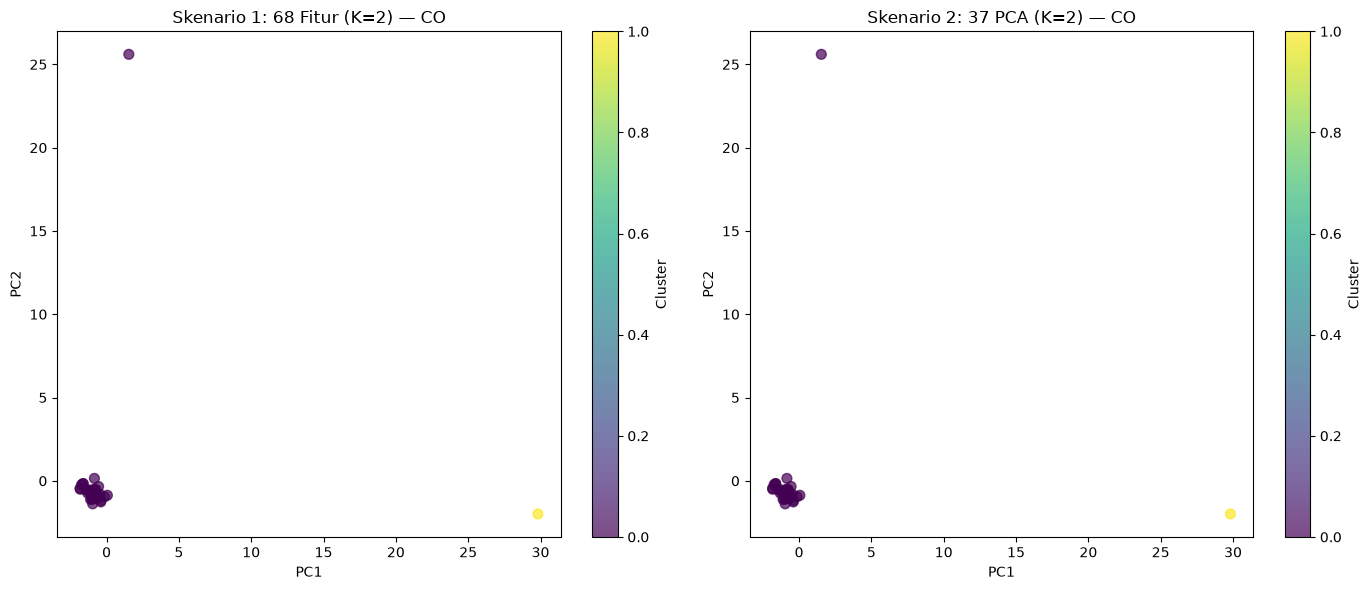

Tersimpan: fig_co_cluster_68.png


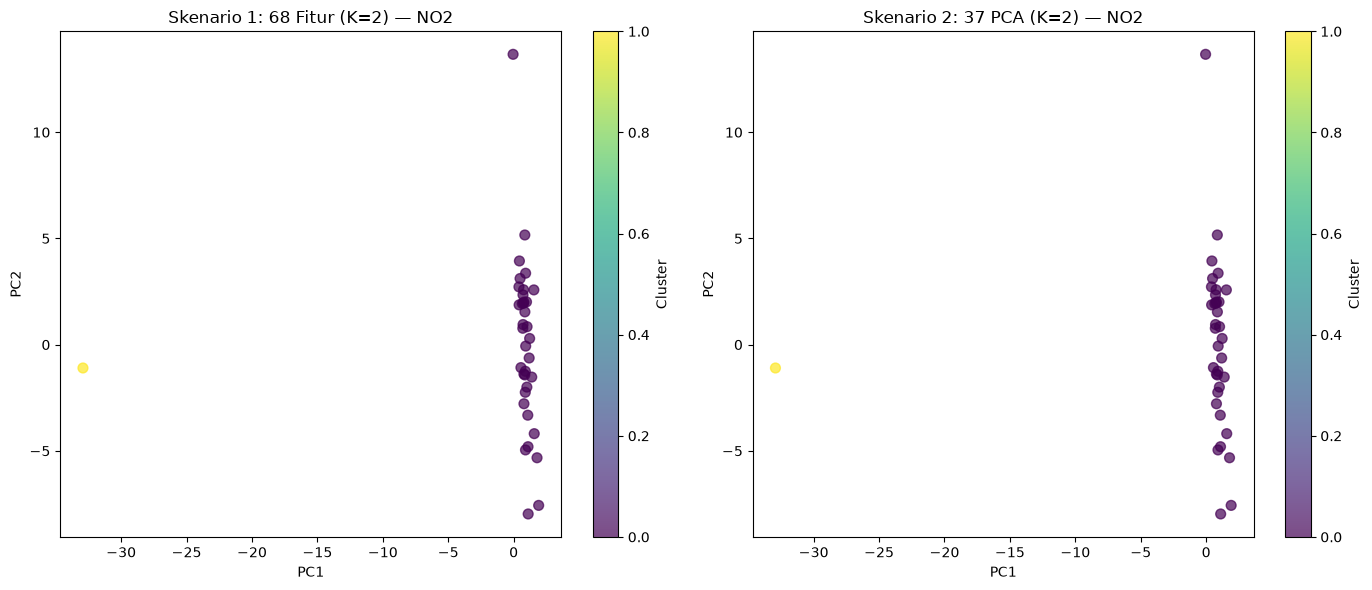

Tersimpan: fig_no2_cluster_68.png


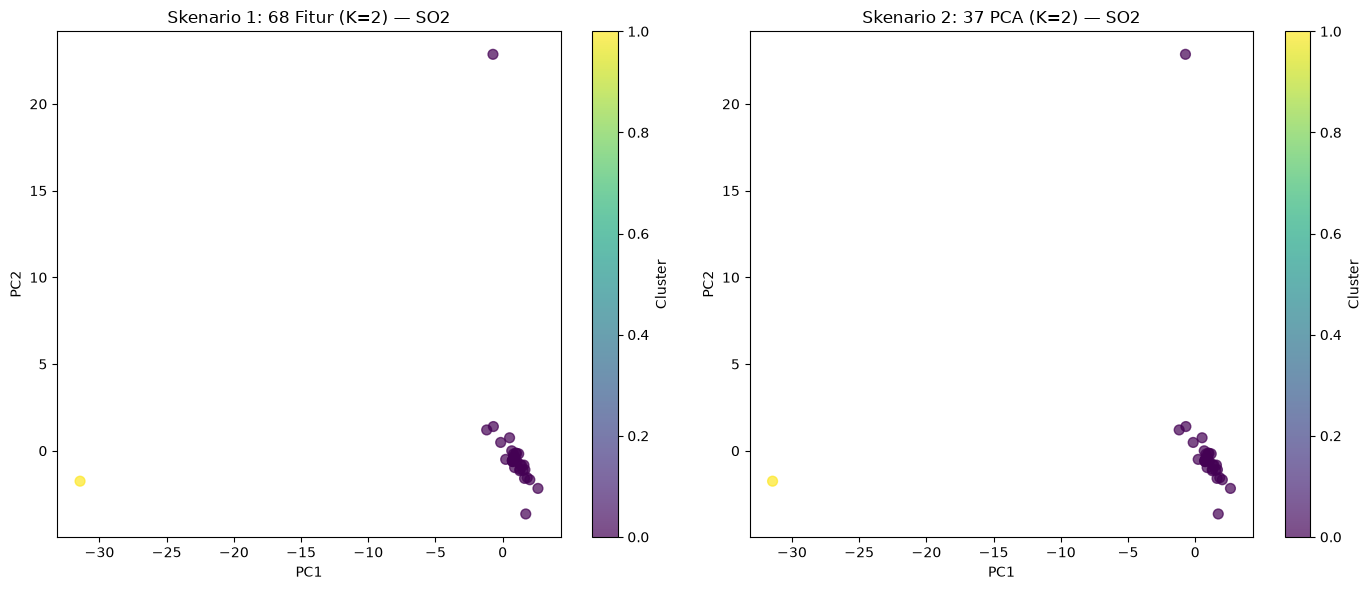

Tersimpan: fig_so2_cluster_68.png


In [9]:
for p in POLLUTANTS:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    best_k_68 = results_68[p]['best_k']
    best_k_pca = results_pca[p]['best_k']
    labels_68 = labels_dict[p]['labels_68']
    labels_pca = labels_dict[p]['labels_pca']
    
    # Proyeksikan ke 2D untuk visualisasi
    pca_2d = PCA(n_components=2)
    X_68_2d = pca_2d.fit_transform(X_scaled_dict[p])
    X_pca_2d = pca_2d.fit_transform(X_pca_dict[p])
    
    # Skenario 1
    scatter1 = ax1.scatter(X_68_2d[:, 0], X_68_2d[:, 1], c=labels_68, cmap='viridis', s=50, alpha=0.7)
    ax1.set_title(f'Skenario 1: 68 Fitur (K={best_k_68}) — {p}')
    ax1.set_xlabel('PC1')
    ax1.set_ylabel('PC2')
    plt.colorbar(scatter1, ax=ax1, label='Cluster')
    
    # Skenario 2
    scatter2 = ax2.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=labels_pca, cmap='viridis', s=50, alpha=0.7)
    ax2.set_title(f'Skenario 2: 37 PCA (K={best_k_pca}) — {p}')
    ax2.set_xlabel('PC1')
    ax2.set_ylabel('PC2')
    plt.colorbar(scatter2, ax=ax2, label='Cluster')
    
    plt.tight_layout()
    plt.savefig(f'../data/images/clustering/{p.lower()}/fig_{p.lower()}_cluster_68.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Tersimpan: fig_{p.lower()}_cluster_68.png')

## 5.2.6 Ringkasan Metrik per Polutan

| Polutan | Skenario | Fitur | K Terbaik | Silhouette Score | Inertia |
|---------|----------|-------|-----------|------------------|---------|
| CO | 1 | 68 | - | - | - |
| CO | 2 | 37 PCA | - | - | - |
| NO₂ | 1 | 68 | - | - | - |
| NO₂ | 2 | 37 PCA | - | - | - |
| SO₂ | 1 | 68 | - | - | - |
| SO₂ | 2 | 37 PCA | - | - | - |

In [10]:
rows = []
for p in POLLUTANTS:
    best_k_68 = results_68[p]['best_k']
    best_sil_68 = results_68[p]['best_sil']
    inertia_68 = results_68[p]['inertias'][best_k_68 - 2]
    
    best_k_pca = results_pca[p]['best_k']
    best_sil_pca = results_pca[p]['best_sil']
    inertia_pca = results_pca[p]['inertias'][best_k_pca - 2]
    
    rows.append({'Polutan': p, 'Skenario': '1 (68 Fitur)', 'Fitur': 68,
                 'K Terbaik': best_k_68, 'Silhouette': round(best_sil_68, 4),
                 'Inertia': round(inertia_68, 2)})
    rows.append({'Polutan': p, 'Skenario': '2 (37 PCA)', 'Fitur': 37,
                 'K Terbaik': best_k_pca, 'Silhouette': round(best_sil_pca, 4),
                 'Inertia': round(inertia_pca, 2)})

df_ringkasan = pd.DataFrame(rows)
df_ringkasan

,Polutan,Skenario,Fitur,K Terbaik,Silhouette,Inertia
0,CO,1 (68 Fitur),68,2,0.7667,1354.50
1,CO,2 (37 PCA),37,2,0.7667,1354.50
2,NO2,1 (68 Fitur),68,2,0.7450,1326.82
3,NO2,2 (37 PCA),37,2,0.7450,1326.82
4,SO2,1 (68 Fitur),68,2,0.7744,1321.99
5,SO2,2 (37 PCA),37,2,0.7744,1321.99


## 5.2.7 Kesimpulan

1. **Silhouette Score** yang lebih tinggi menunjukkan cluster yang lebih terpisah dan compact.
2. Jika Skenario 2 (PCA) menghasilkan silhouette yang lebih baik atau setara → PCA efektif mereduksi noise.
3. Jika Skenario 1 lebih baik → fitur asli masih lebih informatif.
4. Komparasi lengkap ada di notebook 5.3.